
https://www.kaggle.com/code/naubergois/boston-housing-neural-network-beginners-tutorial

Step 1: Import Required Libraries

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.datasets import boston_housing
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


Step 2: Load the Boston Housing Dataset

In [4]:
# Load dataset
(X_train, y_train), (X_test, y_test) = boston_housing.load_data()

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)


57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: (404, 13)
Testing samples: (102, 13)


Step 3: Feature Scaling (Standardization)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Step 4: Design the Neural Network

In [6]:
model = Sequential()

# Input + Hidden layer 1
model.add(Dense(64, activation='relu', input_shape=(13,)))

# Hidden layer 2
model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(1, activation='linear'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 5: Compile the Model

In [7]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Step 6: Train the Model

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 544.9902 - mean_absolute_error: 21.5034 - val_loss: 418.2023 - val_mean_absolute_error: 19.2814
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 478.1636 - mean_absolute_error: 19.6154 - val_loss: 306.3559 - val_mean_absolute_error: 16.2400
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 311.1446 - mean_absolute_error: 15.5528 - val_loss: 165.7091 - val_mean_absolute_error: 11.5032
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 188.4083 - mean_absolute_error: 11.3386 - val_loss: 64.5665 - val_mean_absolute_error: 6.7256
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 71.0083 - mean_absolute_error: 6.6327 - val_loss: 40.2104 - val_mean_absolute_error: 5.3876
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 59.9756 - mean_absolute_error: 5.8169 - val_loss: 28.5647 - val_mean_absolute_error: 4.3973
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 35.4087 - mean_abs

Step 7: Evaluate the Model

In [9]:
test_loss, test_mae = model.evaluate(X_test, y_test)
print("Test Mean Absolute Error:", test_mae)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 12.6055 - mean_absolute_error: 2.3821
Test Mean Absolute Error: 2.5791165828704834


Step 8: Plot Training & Validation Loss

Step 8: Plot Training & Validation Loss

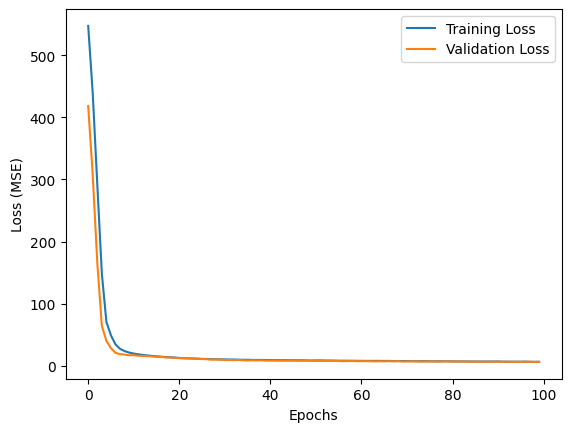

In [12]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()


In [10]:
predictions = model.predict(X_test[:5])

print("Predicted Prices:", predictions.flatten())
print("Actual Prices   :", y_test[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Predicted Prices: [ 8.499553 18.378563 21.60163  33.435658 25.43112 ]
Actual Prices   : [ 7.2 18.8 19.  27.  22.2]
